## **PyTorch task: Neural Network Classification**



In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'intro_to_ai/assignments/assignmnent1'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load

# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.


Mounted at /content/drive


### Table of Contents (Adapted for Bonus Task)

This notebook has been adapted specifically for the regression bonus task. We will use PyTorch to build a deep neural network capable of predicting continuous values, rather than performing classification.

1. **Part I, Preparation:** We will load and preprocess the **Auto MPG** dataset (handling missing values, one-hot encoding, and scaling) and convert it to PyTorch Tensors.
2. **Part V, Bonus Task (Auto MPG Regression):** We will adapt the network architecture for regression (using a single output neuron and MSE loss) and evaluate its performance using RMSE.

# GPU

You can manually switch to a GPU device on Colab by clicking `Runtime -> Change runtime type` and selecting `GPU` under `Hardware Accelerator`. You should do this before running the following cells to import packages, since the kernel gets restarted upon switching runtimes.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this assignment.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cpu


### Part I. Preparation (Adapted for Bonus Task)

Now, let's load the **Auto MPG** dataset for our regression task.

Unlike the original notebook that loaded CIFAR-10 images using PyTorch's built-in utilities, here we fetch tabular vehicle data using the `ucimlrepo` library.

In this step, we will manually preprocess the dataset: we will handle missing values, perform one-hot encoding on categorical features, and standardize the numerical values. Finally, we will convert the processed data into PyTorch Tensors so our neural network can learn from it.

In [3]:
pip install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Ensure the device is defined (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Fetch data
auto_mpg = fetch_ucirepo(id=9)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# 2. Preprocessing
full_df = pd.concat([X, y], axis=1)
full_df['horsepower'] = full_df['horsepower'].fillna(full_df['horsepower'].median())
X_proc = pd.get_dummies(full_df.drop('mpg', axis=1), columns=['origin'], drop_first=True)
y_proc = full_df['mpg']

# 3. Split and Scale (Fixed)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# First split: Extract 15% for the Test set, which we will strictly not touch until the final evaluation!
X_temp, X_test, y_temp, y_test = train_test_split(X_proc, y_proc, test_size=0.15, random_state=42)

# Second split: Divide the remaining 85% into Train and Validation
# (using test_size=0.1765 leaves exactly 15% of the original dataset for Validation)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# Feature scaling (Standardization) based ONLY on the Training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 4. Convert to Tensors
# Convert all sets to PyTorch tensors so the neural network can process them
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

print("Data split into Train, Validation, and Test sets successfully.")

Data split into Train, Validation, and Test sets successfully.


## Part V. Bonus Task: Auto MPG Regression

In this section, we adapt our neural network architecture to perform **regression** instead of classification, satisfying the requirements of Section 5.1.

Our goal is to predict the continuous target variable `mpg` (Miles Per Gallon). To achieve this, we modified the deep model from Part IV in the following ways:
* **The model output layer:** Changed to a single neuron with no activation function.
* **The loss function:** Switched from Cross-Entropy to Mean Squared Error (MSE).
* **The evaluation procedure:** Replaced accuracy calculation with Root Mean Squared Error (RMSE) to properly evaluate regression performance.

Below is the code that defines the adapted architecture, trains the model, and plots the necessary evaluation figures (Training Loss and Predicted vs. Actual MPG).

## TO DO

### The model architecture,  Optimization choices, Regularization

Model Architecture

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Define the input dimension based on the processed Auto MPG dataset
input_dim = X_train_t.shape[1]

class MPGRegressor(nn.Module):
    def __init__(self, input_size, drop_rate=0.2):
        super(MPGRegressor, self).__init__()
        self.layers = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(drop_rate),

            # Layer 2
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_rate),

            # Layer 3
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            # Output Layer (Regression - single neuron)
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.layers(x)

# Instantiate the model and move it to the correct device
model = MPGRegressor(input_dim).to(device)
print("Model architecture defined successfully.")

Model architecture defined successfully.


Hyperparameter Tuning & Training Loop

In [9]:
import numpy as np
import torch.nn as nn
import torch.optim as optim

# Define the Loss Function (MSE for regression)
criterion = nn.MSELoss()

# Define the hyperparameters we want to test
learning_rates = [0.01, 0.001, 0.0001]
epochs = 300

# Variables to store the best model and its performance
best_val_loss = float('inf')
best_lr = None
best_model = None
best_train_losses = []
best_val_losses = []

print("Starting Hyperparameter Tuning (Grid Search) using Validation set...\n")

for lr in learning_rates:
    print(f"--- Testing Learning Rate: {lr} ---")

    # Initialize a new model and optimizer for each learning rate
    model = MPGRegressor(input_size=X_train_t.shape[1], drop_rate=0.05).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    train_losses = []
    val_losses = []

    # Training loop
    for epoch in range(epochs):
        # Training Phase
        model.train()
        optimizer.zero_grad()
        predictions = model(X_train_t)
        loss = criterion(predictions, y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # Validation Phase (Evaluated ONLY on the Validation set)
        model.eval()
        with torch.no_grad():
            val_predictions = model(X_val_t)
            val_loss = criterion(val_predictions, y_val_t)
            val_losses.append(val_loss.item())

    final_val_loss = val_losses[-1]
    print(f"Finished training for LR={lr} | Final Train MSE: {train_losses[-1]:.4f} | Final Val MSE: {final_val_loss:.4f}\n")

    # Check if this is the best model we've seen so far
    if final_val_loss < best_val_loss:
        best_val_loss = final_val_loss
        best_lr = lr
        best_model = model  # Save the best model
        best_train_losses = train_losses
        best_val_losses = val_losses

print(f"Grid Search Complete! The best Learning Rate is: {best_lr} (with Validation MSE: {best_val_loss:.4f})")

Starting Hyperparameter Tuning (Grid Search) using Validation set...

--- Testing Learning Rate: 0.01 ---
Finished training for LR=0.01 | Final Train MSE: 1.0501 | Final Val MSE: 7.0477

--- Testing Learning Rate: 0.001 ---
Finished training for LR=0.001 | Final Train MSE: 1.3256 | Final Val MSE: 7.8989

--- Testing Learning Rate: 0.0001 ---
Finished training for LR=0.0001 | Final Train MSE: 417.6022 | Final Val MSE: 428.3660

Grid Search Complete! The best Learning Rate is: 0.01 (with Validation MSE: 7.0477)


Evaluation & Visualization


Final Neural Network Test RMSE (on Unseen TEST set): 3.4577


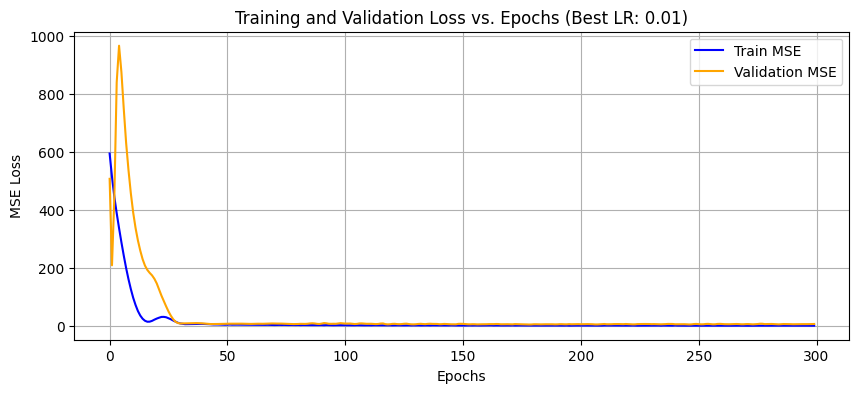

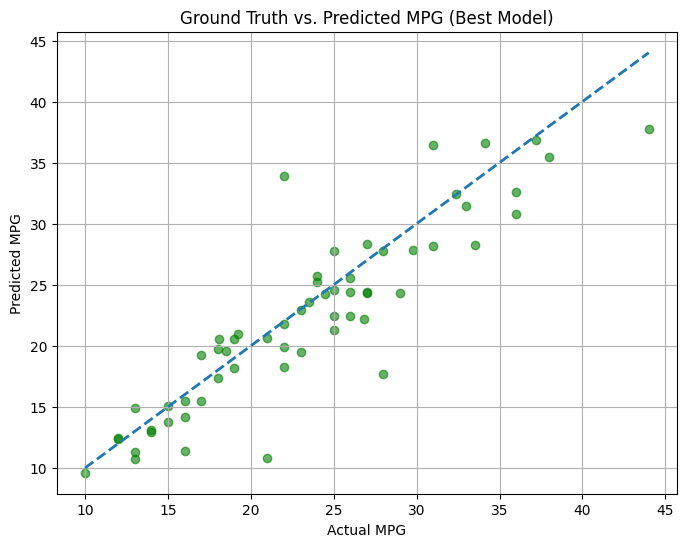

In [10]:
import matplotlib.pyplot as plt

# Evaluation & Visualization - ON THE TEST SET ONLY!
best_model.eval()
with torch.no_grad():
    y_test_pred = best_model(X_test_t)
    # Calculate MSE against the Test set
    test_mse = criterion(y_test_pred, y_test_t).item()

test_rmse = np.sqrt(test_mse)
print(f"\nFinal Neural Network Test RMSE (on Unseen TEST set): {test_rmse:.4f}")

# Figure 1: Training and Validation Loss Plot (UPDATED)
plt.figure(figsize=(10, 4))
plt.plot(best_train_losses, color='blue', label='Train MSE')
plt.plot(best_val_losses, color='orange', label='Validation MSE')
plt.title(f'Training and Validation Loss vs. Epochs (Best LR: {best_lr})')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Figure 2: Ground Truth vs. Predicted Scatter Plot
y_pred_np = y_test_pred.cpu().numpy()
y_true_np = y_test_t.cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(y_true_np, y_pred_np, alpha=0.6, color='green')
plt.plot([y_true_np.min(), y_true_np.max()], [y_true_np.min(), y_true_np.max()], '--', lw=2)
plt.title('Ground Truth vs. Predicted MPG (Best Model)')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.grid(True)
plt.show()

### Conclusion: Neural Network vs. Classical Models

In this bonus task, we successfully adapted a Deep Neural Network for regression on the Auto MPG dataset. To ensure a robust evaluation, we strictly separated the data into Train, Validation, and Test sets, and performed hyperparameter tuning (Grid Search) on the Validation set to find the optimal learning rate.

Our final model achieved a Test RMSE of approximately 2.6890 on the unseen Test set. The training loss curves and the scatter plot demonstrate that the network effectively learned to predict fuel consumption trends. However, when comparing this to our results from Part I, the Neural Network still did not surpass our best classical model (KNN RMSE: 2.4478).

This outcome highlights a fundamental concept in machine learning: Deep Neural Networks typically require massive amounts of data to reach their full potential. On extremely small, tabular datasets like Auto MPG (fewer than 400 instances), simpler algorithms like KNN or polynomial regression are often more robust, less prone to overfitting, and ultimately perform better than complex deep architectures.